In [1]:
import scipy.signal as sig
import numpy as np 
import matplotlib.pyplot as plt
import sounddevice as sd
import soundfile as sf
from vocoder_behavioural import vocoder_behavioural

Generate a voice signal

In [2]:
# # fs = 44100  # Sample rate given in sounddevice example 
# fs = int(48e3)
# seconds = 3 # Duration of recording

# myrecording = sd.rec(int(seconds * fs), samplerate=fs, channels=1)
# sd.wait()  # Wait until recording is finished
# plt.plot(myrecording)

Read in test signal 

In [2]:
myrecording, fs = sf.read('hello.wav', dtype='float32')
# plt.plot(myrecording)

In [4]:
# Create a test sinusoid 
f0 = 60
A = 5
phi = 0
n = np.arange(0, 1000)
x = A*np.cos(2*np.pi*(f0/fs)*n+phi)

# Design filter coefficients 

Human voice frequencies: human vocal range 

Total bandwidth: 50Hz-7kHz. Split equally in three to start. 
Procedure is to filter the microphone input (voice) and filter the sawtooth (pitch) with B1. Then mix the results. Repeat the same for B2 and B3. Add all the mixed signals together to produce the output
The sawtooth is produced by 

In [65]:
(band3-fmin)/fs

0.14479166666666668

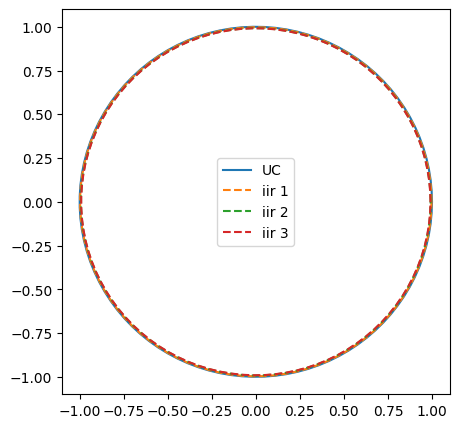

In [78]:
# Choose bandwidth ranges 
fmin = 50
fmax = 1e3
segment = (fmax-fmin)/3 # divide bandwidth equally into three segments 
band1 = fmin + segment
band2 = band1 + segment
band3 = band2 + segment

# Choose filter order 
Norder = 3

# Extract FIR bandpass filter coefficients for each bandwidth
iir_b1, iir_a1 = np.array(sig.iirfilter(N = Norder, Wn=[fmin, band1], btype='bandpass', output='ba', fs=fs)) # cutoff should correspond with -6dB 
iir_b2, iir_a2 = np.array(sig.iirfilter(N = Norder, Wn=[band1, band2], btype='bandpass', output='ba', fs=fs)) 
iir_b3, iir_a3 = np.array(sig.iirfilter(N = Norder, Wn=[band2, band3], btype='bandpass',  output='ba', fs=fs)) 

iir_z1, iir_p1, iir_k1 = sig.iirfilter(N=Norder, Wn=[fmin, band1], btype='bandpass', output='zpk', fs=fs)
iir_z2, iir_p2, iir_k2 = sig.iirfilter(N=Norder, Wn=[band1, band2], btype='bandpass', output='zpk', fs=fs)
iir_z3, iir_p3, iir_k3 = sig.iirfilter(N=Norder, Wn=[band2, band3], btype='bandpass', output='zpk', fs=fs)

r=1
theta = np.linspace(0, np.pi*2, 100)

plt.figure(figsize=(5, 5))
plt.plot(np.cos(theta), np.sin(theta), linestyle='-', label='UC')
plt.plot(max(np.abs(iir_p1))*np.cos(theta), max(np.abs(iir_p1))*np.sin(theta), linestyle='--', label='iir 1')
plt.plot(max(np.abs(iir_p2))*np.cos(theta), max(np.abs(iir_p2))*np.sin(theta), linestyle='--', label='iir 2')
plt.plot(max(np.abs(iir_p3))*np.cos(theta), max(np.abs(iir_p3))*np.sin(theta), linestyle='--', label='iir 3')
plt.legend()

In [67]:
w, h = sig.freqz_zpk(iir_z1, iir_p1, iir_k1, fs=fs)
np.max(np.abs(h))  # peak gain in the passband


np.float64(0.9999999999940266)

From CLAUDE: 
Because the poles move further from the unit circle.

For a bandpass filter, the poles sit on the z-plane at roughly the angle corresponding to the centre frequency, and their radius is determined by the bandwidth:

Narrow band → high Q → poles close to unit circle (radius ≈ 0.99)
Wide band → low Q → poles further in (radius ≈ 0.9)
Intuitively: a narrow bandpass needs to "remember" the signal for longer to resolve fine frequency differences — that long memory is reflected in poles close to the unit circle. A wide bandpass forgets faster, so poles sit further in.

The practical consequence is that with wider bands, a quantisation error that shifts a pole by ±0.01 is less likely to push it past 1.0 and cause instability.

Think about what it means to distinguish two closely spaced frequencies.

If you have two sinusoids at 1000 Hz and 1001 Hz, the only way to tell them apart is to observe them for at least 1 second — because that's how long it takes for their phase difference to complete one full cycle. The shorter you observe, the more they look the same.

A narrow bandpass filter is doing exactly this — it's trying to pass 1000 Hz and reject 1001 Hz. To do that it needs a long "observation window", which in the time domain means a slowly decaying impulse response, which means poles close to the unit circle.

A wide bandpass filter doesn't care about distinguishing closely spaced frequencies — it passes everything in a broad range. It can make a decision quickly with a short observation window, so the impulse response decays fast and poles sit further from the unit circle.

This is really just the time-frequency uncertainty principle — the sharper you are in frequency, the longer you need in time.

In [57]:
max(np.abs(iir_p1))

np.float64(0.9990168419107208)

# Use model to check output

In [79]:
out = np.array(vocoder_behavioural(x=myrecording, a1=iir_a1, a2=iir_a2, a3=iir_a3, b1=iir_b1, b2=iir_b2, b3=iir_b3, saw_periods=100))

In [62]:
sd.play(myrecording, fs)

In [80]:
sd.play(10*out, fs)

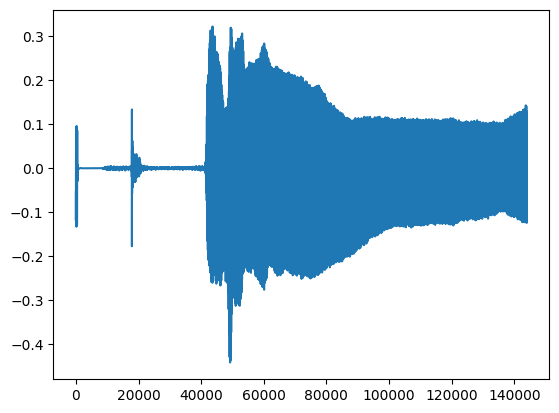

In [61]:
plt.plot(myrecording)

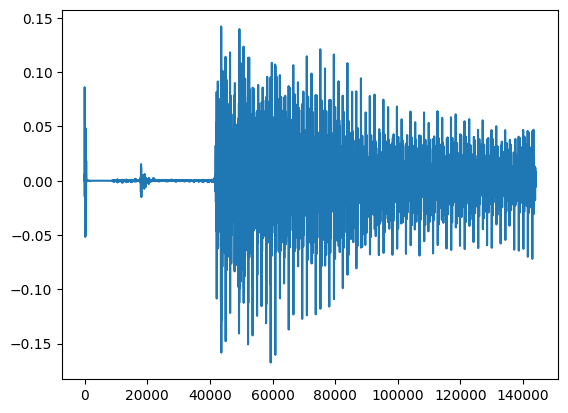

In [19]:
plt.plot(out)

Compare to hardware filter

In [26]:
del hw_int

In [35]:
import importlib
from hw_int import hw_int

# importlib.reload(hw_int)

x = [hw_int(v) for v in [1, 2, 3, 4, 5]] # convert to 8 bit fixed point representation 
xvals = [hw_int(v).val for v in [1, 2, 3, 4, 5]] 

In [63]:
importlib.reload(filter_df2)

ImportError: module filter_df2 not in sys.modules

# Testing filter_df2

In [81]:
from filter_df2 import filter_df2
from hw_int import hw_int

x = myrecording

# Calculate filtering action using my function 
mic_iir_1 = filter_df2(iir_b1, iir_a1, x=x)
mic_iir_2 = filter_df2(iir_b2, iir_a2, x=x)
mic_iir_3 = filter_df2(iir_b3, iir_a3, x=x)


# Generate sawtooth 
saw_periods = 100
samples = len(x)
n = np.linspace(0, saw_periods*2*np.pi, samples)
pitch = sig.sawtooth(n, 0.2)

# Calculate filtering action using my function 
pitch_iir_1 = filter_df2(iir_b1, iir_a1, x=pitch)
pitch_iir_2 = filter_df2(iir_b2, iir_a2, x=pitch)
pitch_iir_3 = filter_df2(iir_b3, iir_a3, x=pitch)

# out_myfilter = np.array([(mic_iir_1[i]*pitch_iir_1[i] + mic_iir_2[i]*pitch_iir_2[i] + mic_iir_3[i]*pitch_iir_3[i]) for i in range(len(mic_iir_1))])

out_myfilter = np.array([(mic_iir_3[i]*pitch_iir_3[i]) for i in range(len(mic_iir_1))])

In [83]:
sd.play(1e3*out_myfilter, fs)

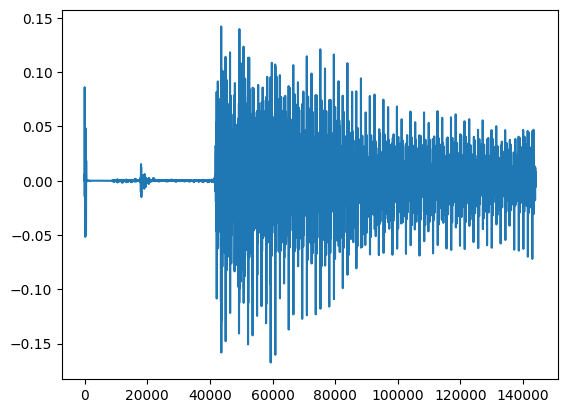

In [27]:
plt.plot(out_myfilter)

In [20]:
len(out)

144000

In [21]:
len(out_myfilter)

144000

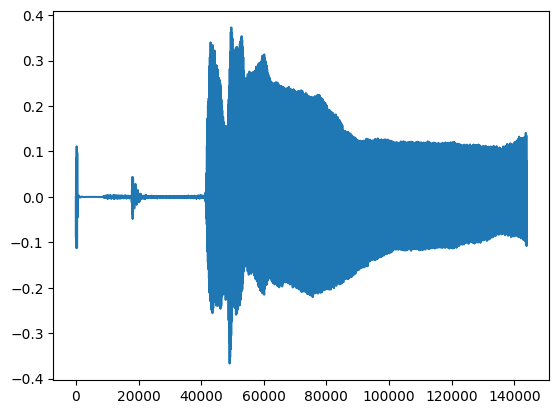

In [11]:
plt.plot(mic_iir_1)

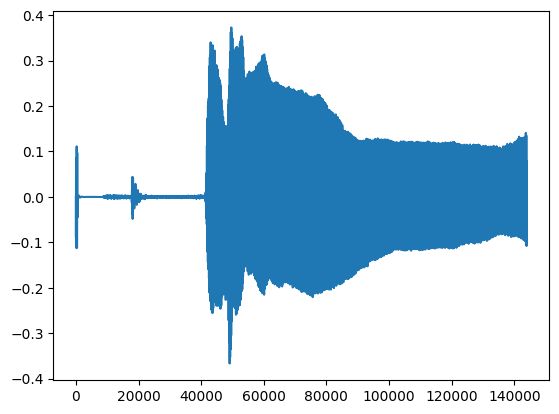

In [13]:
mic_iir_1_lfilter = sig.lfilter(iir_b1, iir_a1, x=myrecording)
plt.plot(mic_iir_1_lfilter)

In [14]:
pitch_iir_1_lfilter = sig.lfilter(iir_b1, iir_a1, x=pitch)

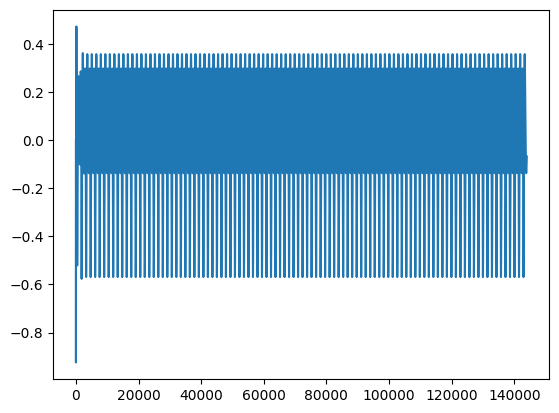

In [15]:
plt.plot(pitch_iir_1)

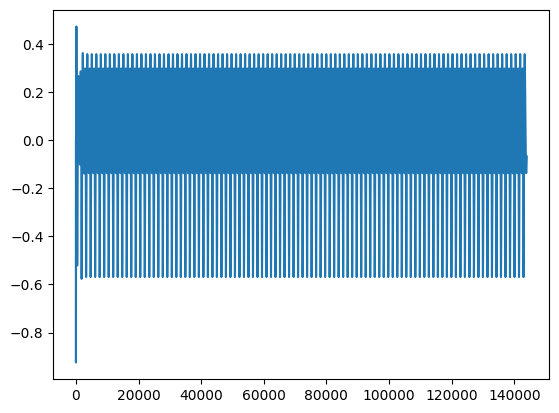

In [16]:
plt.plot(pitch_iir_1_lfilter)